c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
	 Lancement de la modélisation Random Forest


c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\03_models\scores_grid.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['Très petit' 'Petit' 'Moyen' 'Gros' 'Très gros']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[mask, 'Modalité'] = df.loc[mask, 'Modalité'].apply(


		 > Meilleurs paramètres trouvés :
			 {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 300}

		 > Grille de poids des modalités :
			                  Variable       Modalité      Poids
			 0            CLASSE_PMG_N     Très petit   0.000000
			 1            CLASSE_PMG_N          Petit  15.873684
			 2            CLASSE_PMG_N          Moyen  22.053850
			 3            CLASSE_PMG_N           Gros  22.928142
			 4            CLASSE_PMG_N      Très gros  20.246399
			 5   FL_RELATION_CLIENT_3M           Faux   0.000000
			 6   FL_RELATION_CLIENT_3M           Vrai   7.910640
			 7   FL_RELATION_CLIENT_6M           Faux   0.000000
			 8   FL_RELATION_CLIENT_6M           Vrai   3.776685
			 9   FL_RELATION_CLIENT_9M           Faux   0.000000
			 10  FL_RELATION_CLIENT_9M           Vrai   3.756933
			 11           FL_RF_GP_AD4           Faux   0.000000
			 12           FL_RF_GP_AD4           Vrai   3.425985


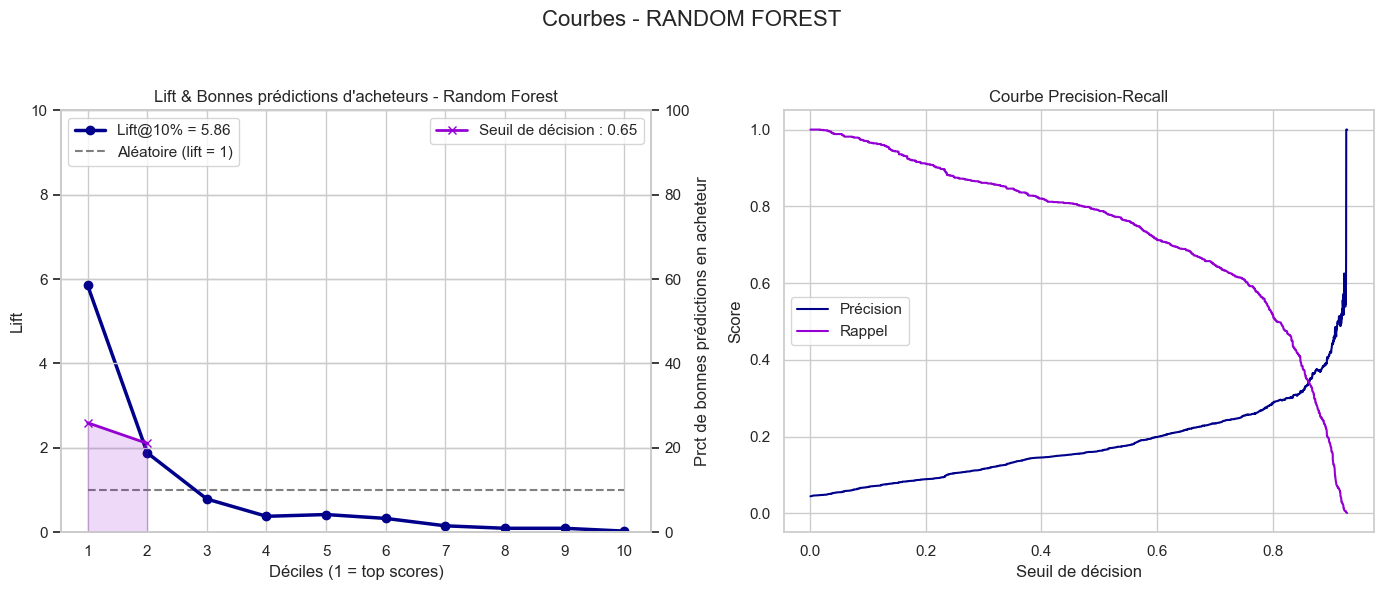

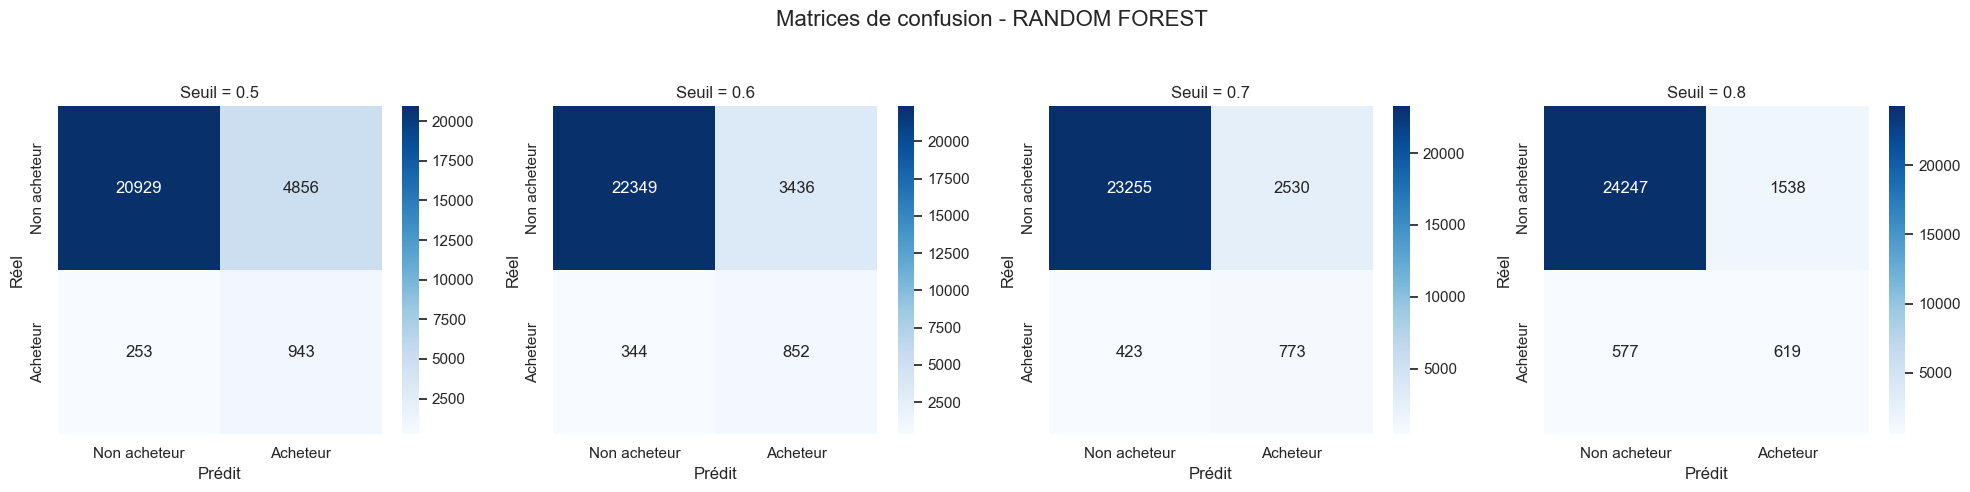

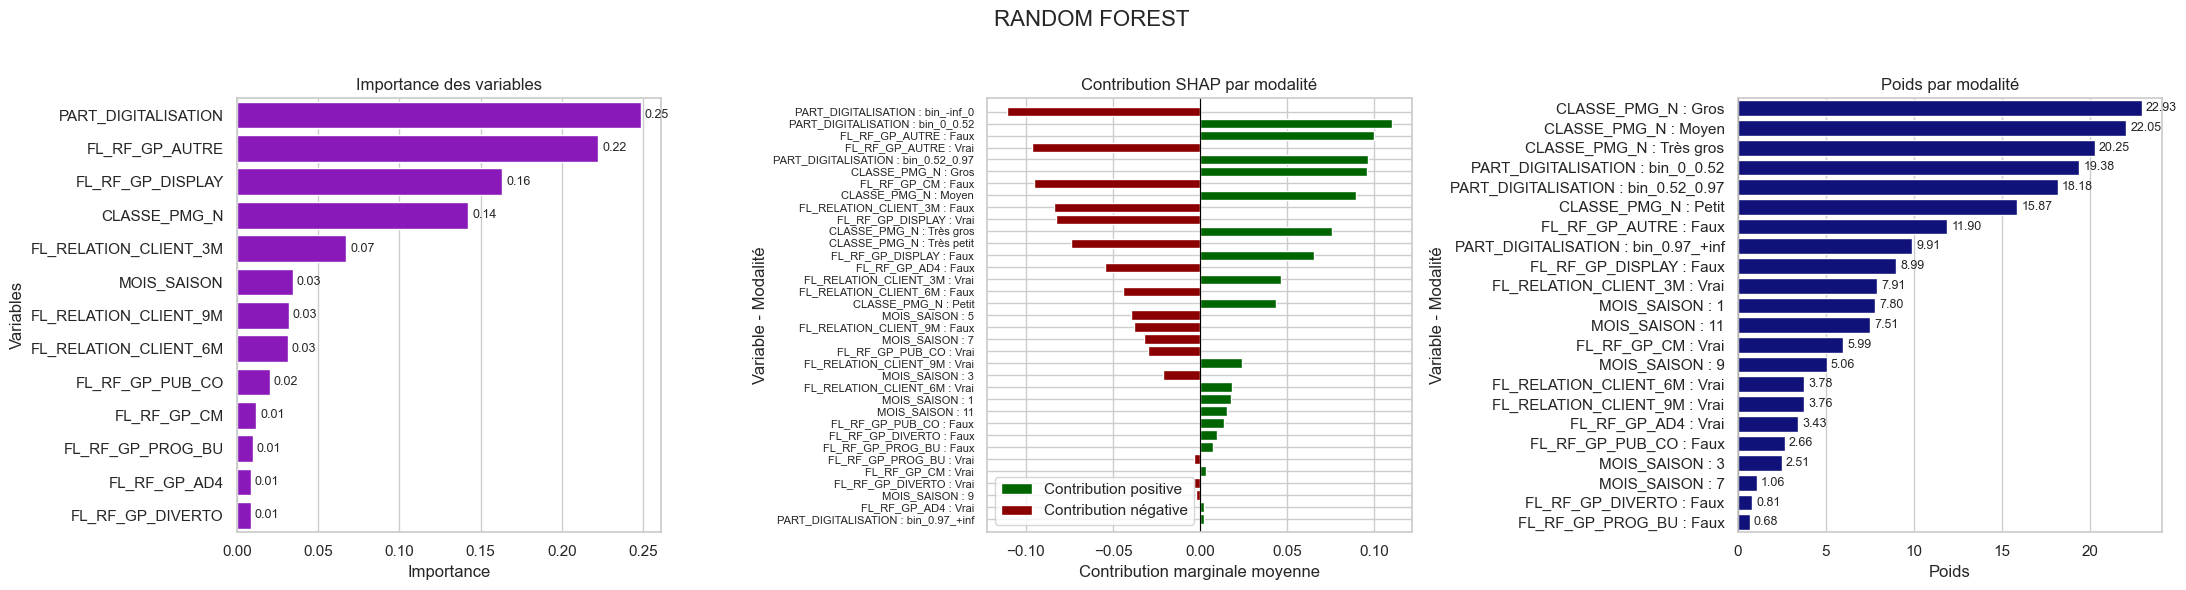

	 Modélisation Random Forest terminée.
---


In [ ]:
# Importation des bibliothèques
import sys
import os
import warnings

import numpy as np
import pandas as pd
import xgboost 


# Import du connecteur
sys.path.append(os.path.abspath("C:/Users/prince.mezuirotimi/OneDrive - Gedeon - SIPAOF/Documents/INTRASIPA/PROJETS/_setup"))
import environnement as env

# Import des fichiers de preparation des données à la modelisation
sys.path.append(os.path.abspath("C:/Users/prince.mezuirotimi/OneDrive - Gedeon - SIPAOF/Documents/INTRASIPA/PROJETS/ADDITI - SCORING APPETENCE PRODUIT/03_models"))
from logistic_regression import apply_logistic_regression
from random_forest import apply_random_forest
from XGBoost import apply_xgboost

def run_models(data_train: pd.DataFrame,
              data_val: pd.DataFrame,
              data_test: pd.DataFrame,
              dict_encode_mapping: dict = None,
              target: str = 'FL_ACHAT_PRODUIT',
              model_selected: list|str = 'all',
              threshold_decision: float = 0.5,
              beta: float = 1.0,
              lift_prct: int = 10)  -> dict:
    """
    Fonction pour exécuter les modèles de régression logistique et Random Forest.
    
    Paramètres :
        data_train : pd.DataFrame
            Jeu de données d'entraînement.
        data_val : pd.DataFrame
            Jeu de données de validation.
        data_test : pd.DataFrame
            Jeu de données de test.
        target : str
            Nom de la colonne cible.
    
    Retour :
        None
    """
    dict_summary_models = {}
    
    if model_selected == 'all' or 'logistic_regression' in model_selected:   
        # Exécution du modèle de régression logistique
        model_name, mdl, scores_grid = apply_logistic_regression(data_train=data_train, data_val=data_val, data_test=data_test, dict_encode_mapping=dict_encode_mapping, target=target, threshold_decision=threshold_decision, beta=beta, lift_prct=lift_prct)
        dict_summary_models[model_name] = [model_name, mdl, scores_grid]

    if model_selected == 'all' or 'random_forest' in model_selected:
        # Exécution du modèle Random Forest
        model_name, mdl, scores_grid = apply_random_forest(data_train=data_train, data_val=data_val, data_test=data_test, dict_encode_mapping=dict_encode_mapping, target=target, threshold_decision=threshold_decision, beta=beta, lift_prct=lift_prct)
        dict_summary_models[model_name] = [model_name, mdl, scores_grid]

    if model_selected == 'all' or 'xgboost' in model_selected:
        # Exécution du modèle XGBoost
        model_name, mdl, scores_grid = apply_xgboost(data_train=data_train, data_val=data_val, data_test=data_test, dict_encode_mapping=dict_encode_mapping, target=target, threshold_decision=threshold_decision, beta=beta, lift_prct=lift_prct)
        dict_summary_models[model_name] = [model_name, mdl, scores_grid]
    
    # Retour des modèles sélectionnés
    return dict_summary_models





# # Test de la fonction run_models
if __name__ == "__main__":
    current_date_heure = '20250814_00h53'
    # Importer les données d'entraînement, de validation et de test
    data_train = pd.read_csv(r'C:/Users/prince.mezuirotimi/OneDrive - Gedeon - SIPAOF/Documents/INTRASIPA/PROJETS/ADDITI - SCORING APPETENCE PRODUIT/00_archives/data_train{}.csv'.format(current_date_heure), sep=';', encoding='utf-8-sig', index_col=0)
    data_val = pd.read_csv(  r'C:/Users/prince.mezuirotimi/OneDrive - Gedeon - SIPAOF/Documents/INTRASIPA/PROJETS/ADDITI - SCORING APPETENCE PRODUIT/00_archives/data_val{}.csv'.format(current_date_heure),   sep=';', encoding='utf-8-sig', index_col=0)
    data_test = pd.read_csv( r'C:/Users/prince.mezuirotimi/OneDrive - Gedeon - SIPAOF/Documents/INTRASIPA/PROJETS/ADDITI - SCORING APPETENCE PRODUIT/00_archives/data_test{}.csv'.format(current_date_heure),  sep=';', encoding='utf-8-sig', index_col=0)

    # Typage des données
    # Sélectionner les colonnes numériques hors booléens
    num_cols = data_train.select_dtypes(include=['number']).columns
    bool_cols = data_train.select_dtypes(include=['bool']).columns

    # Colonnes numériques hors booléens
    num_cols_to_convert = [col for col in num_cols if col not in bool_cols]

    data_train[num_cols_to_convert] = data_train[num_cols_to_convert].astype('category')
    data_val[num_cols_to_convert] = data_val[num_cols_to_convert].astype('category')
    data_test[num_cols_to_convert] = data_test[num_cols_to_convert].astype('category')

    # Dictionnaire de mapping de l'encodage
    dict_encode_mapping = {}
    dict_encode_mapping['MOIS_SAISON'] = {'8': 0, '7': 1, '5': 2, '6': 3, '3': 4, '9': 5, '4': 6, '11': 7, '2': 8, '1': 9, '10': 10, '12': 11, '<inconnu>': -1}
    dict_encode_mapping['CLASSE_PMG_N'] = {'Très petit': 0, 'Petit': 1, 'Moyen': 2, 'Gros': 3, 'Très gros': 4, '<inconnu>': -1}
    dict_encode_mapping['PART_DIGITALISATION'] = {'bin_-inf_0': 0, 'bin_0_0.52': 1, 'bin_0.52_0.97': 2, 'bin_0.97_+inf': 3, '<inconnu>': -1}

    # Appeler la fonction run_models
    models = run_models(data_train=data_train,
                                data_val=data_val,
                                data_test=data_test,
                                dict_encode_mapping=dict_encode_mapping,
                                target='FL_ACHAT_PRODUIT',
                                model_selected=['random_forest'], # 'all' = 'logistic_regression', 'random_forest', 'xgboost'
                                threshold_decision=0.65,
                                beta=0.5,
                                lift_prct=10
                            )
    
    # Sauvergarde des modèles
    models_df = pd.DataFrame([
        {
            'model_name': model_info[0],                # model_name
            'model_sklearn': str(model_info[1]), # mdl (modèle sklearn converti en chaîne)
        }
        for model_info in models.values()
    ])
    models_df.to_excel(f'C:/Users/prince.mezuirotimi/OneDrive - Gedeon - SIPAOF/Documents/INTRASIPA/PROJETS/ADDITI - SCORING APPETENCE PRODUIT/00_archives/models_details_{current_date_heure}.xlsx', index=False)

    # Sauvegardes des grilles
    for model_info in models.values():
        scores_grid = model_info[2]
        scores_grid.to_csv(f'C:/Users/prince.mezuirotimi/OneDrive - Gedeon - SIPAOF/Documents/INTRASIPA/PROJETS/ADDITI - SCORING APPETENCE PRODUIT/00_archives/models_grid_{model_info[0]}_{current_date_heure}.csv', sep=';', index=True, header=True, encoding='utf-8-sig')